1. Dataset Loading and Visualization:
● Load the provided time series dataset.
● Ensure that the dataset includes a proper datetime column and is set as the index.
● Handle any missing values or outliers appropriately.
● Visualize the time series data to explore trends, seasonality, and anomalies

(140256, 370)
                     MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  MT_007  \
date                                                                          
2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

                     MT_008  MT_009  MT_010  ...  MT_361  MT_362  MT_363  \
date                                         ...                           
2011-01-01 00:15:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:30:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 00:45:00     0.0     0.0     0.0  ...     0.0     0.0     0.0   
2011-01-01 01:00:00     0.0     0.0     0.0  ...    

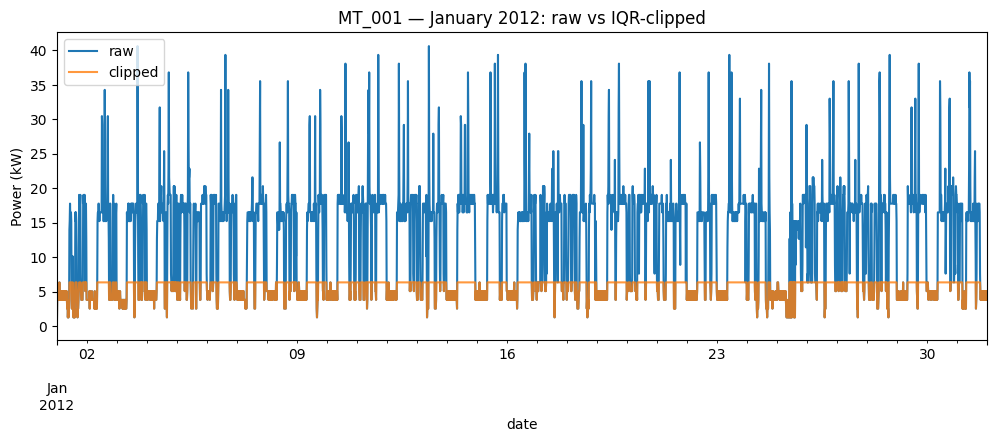

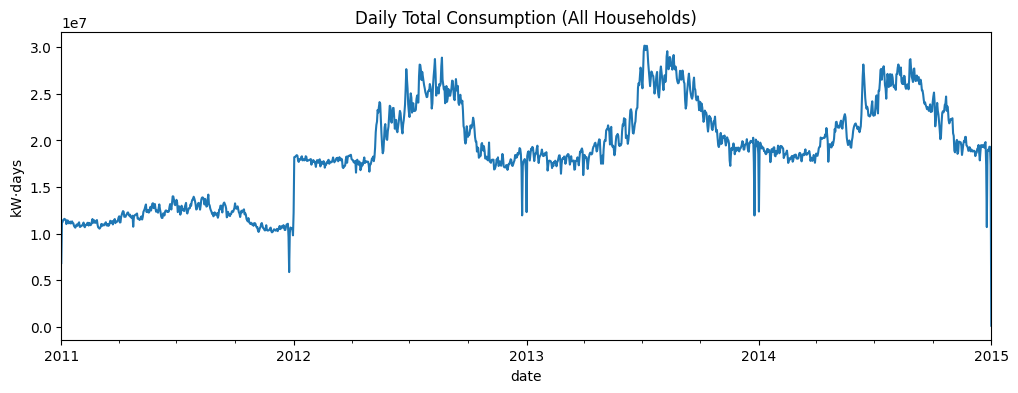

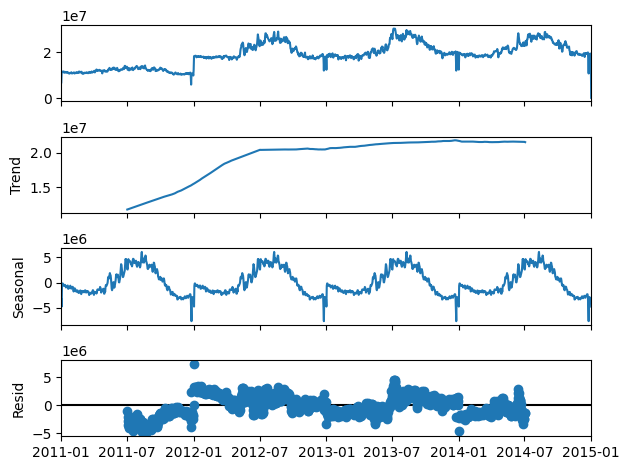

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load as CSV:
df = pd.read_csv(
    "LD2011_2014.txt",   
    sep=";",                                 
    decimal=",",                        
    parse_dates=[0],                     
    dayfirst=False,                     
    index_col=0,                         
    na_values=[""],                           
)

# Peek at the shape & head
# print(df.shape)
# print(df.head())

# 2. Check for missing values (should be none per documentation)
print("Missing values per column:", df.isna().sum().sum())

# 3. Simple outlier check via IQR for one household (e.g. MT_001)
series = df["MT_001"]
Q1, Q3 = series.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = series[(series < lower) | (series > upper)]
print(f"Found {len(outliers)} outliers in MT_001")

# Optionally cap them:
series_clipped = series.clip(lower, upper)
df["MT_001_clipped"] = series_clipped

# 4. Visualize raw vs. clipped for a month
plt.figure(figsize=(12,4))
series["2012-01"].plot(label="raw")
series_clipped["2012-01"].plot(label="clipped", alpha=0.8)
plt.legend()
plt.title("MT_001 — January 2012: raw vs IQR-clipped")
plt.ylabel("Power (kW)")
plt.show()

# 5. Aggregate across all households (daily sum) to see overall trend & seasonality
daily = df.sum(axis=1).resample("D").sum()
plt.figure(figsize=(12,4))
daily.plot()
plt.title("Daily Total Consumption (All Households)")
plt.ylabel("kW·days")
plt.show()

# 6. Seasonal decomposition on the aggregate
decomp = seasonal_decompose(daily, model="additive", period=365)
decomp.plot()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import holidays

# Resample to daily total consumption ---
daily = df.sum(axis=1).resample('D').sum().to_frame(name='total_kW')

# Lag features & rolling-window stats ---
lags = [1, 2, 3, 7, 14]
for lag in lags:
    daily[f'lag_{lag}'] = daily['total_kW'].shift(lag)

windows = [7, 14, 30]
for w in windows:
    daily[f'roll_mean_{w}'] = daily['total_kW'].rolling(w).mean()
    daily[f'roll_std_{w}']  = daily['total_kW'].rolling(w).std()
    daily[f'roll_min_{w}']  = daily['total_kW'].rolling(w).min()
    daily[f'roll_max_{w}']  = daily['total_kW'].rolling(w).max()

# --- 2.3 Time-based features ---
daily['day_of_week'] = daily.index.dayofweek             # 0=Mon … 6=Sun
daily['day_of_month'] = daily.index.day
daily['month']        = daily.index.month
daily['is_weekend']   = daily['day_of_week'].isin([5,6]).astype(int)

# Yearly cycle: encode day-of-year as sin/cos
daily['day_of_year'] = daily.index.dayofyear
daily['sin_doy'] = np.sin(2 * np.pi * daily['day_of_year'] / 365.25)
daily['cos_doy'] = np.cos(2 * np.pi * daily['day_of_year'] / 365.25)

# Weekly cycle: encode day-of-week as sin/cos
daily['sin_dow'] = np.sin(2 * np.pi * daily['day_of_week'] / 7)
daily['cos_dow'] = np.cos(2 * np.pi * daily['day_of_week'] / 7)

# Weekend flag
daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

print(daily[['sin_doy','cos_doy','sin_dow','cos_dow','is_weekend']].head())

# Holiday flag for Portugal
pt_holidays = holidays.PT(years=daily.index.year.unique())
daily['is_holiday'] = daily.index.to_series().apply(lambda d: int(d in pt_holidays))

# --- 2.4 Drop initial NaNs from shifting/rolling ---
daily = daily.dropna()

# --- 2.5 Normalize features ---
feature_cols = [c for c in daily.columns if c != 'total_kW']
scaler = MinMaxScaler()
daily[feature_cols] = scaler.fit_transform(daily[feature_cols])


# Create sliding-window sequences ---
def make_sequences(data: np.ndarray, seq_len: int):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len, :])        # all features
        y.append(data[i + seq_len, 0])            # target is first column: total_kW
    return np.array(X), np.array(y)

SEQ_LEN = 30 
arr = daily.to_numpy()
X, y = make_sequences(arr, SEQ_LEN)

print("Features shape:", X.shape)   # (n_samples, 30, n_features)
print("Target  shape:", y.shape)   # (n_samples,)

             sin_doy   cos_doy   sin_dow   cos_dow  is_weekend
date                                                          
2011-01-01  0.017202  0.999852 -0.974928 -0.222521           1
2011-01-02  0.034398  0.999408 -0.781831  0.623490           1
2011-01-03  0.051584  0.998669  0.000000  1.000000           0
2011-01-04  0.068755  0.997634  0.781831  0.623490           0
2011-01-05  0.085906  0.996303  0.974928 -0.222521           0
Features shape: (1403, 30, 28)
Target  shape: (1403,)


3. Forecasting with a Classical Deep Learning Approach
● Use a sequence-based model from the following: LSTM, RNN, MLP
● Define an appropriate input-output window for training and prediction
● Train and validate the model using time series cross-validation
● Visualize and compare predictions vs actual values.
● Report metrics such as MAE, RMSE, and MAPE.


Fold 1 | Epoch 001 | Train MSE: 0.0565 | Val MSE: 0.0070
Fold 1 | Epoch 050 | Train MSE: 0.0012 | Val MSE: 0.0052
Fold 1 final MAE: 1630505.4 kW



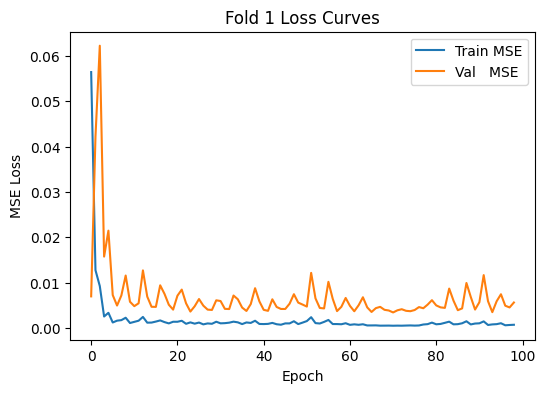

Fold 2 | Epoch 001 | Train MSE: 0.0745 | Val MSE: 0.0295
Fold 2 | Epoch 050 | Train MSE: 0.0013 | Val MSE: 0.0019
Fold 2 final MAE: 1128598.0 kW



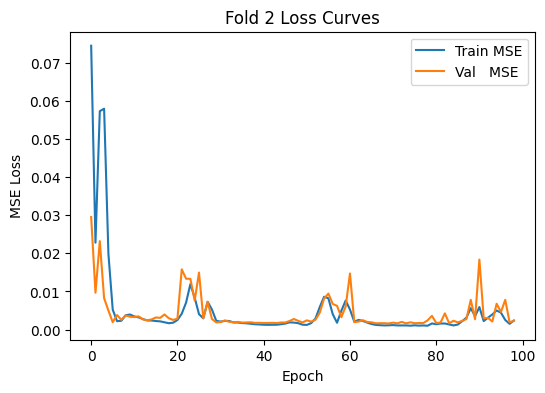

Fold 3 | Epoch 001 | Train MSE: 0.0421 | Val MSE: 0.0396
Fold 3 | Epoch 050 | Train MSE: 0.0022 | Val MSE: 0.0038
Fold 3 final MAE: 782470.5 kW



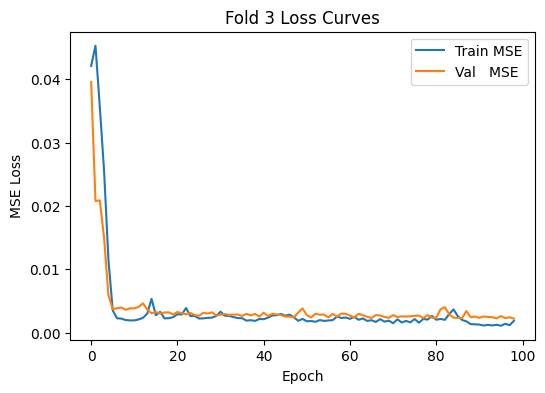

▶︎ Average MAE across folds: 1180524.6 kW


In [ ]:
# Cell 4b (revised): Larger LSTM, full scaling, longer training, loss curves

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

# --- 0) Scale all features + target into [0,1] ---
feature_cols = daily.columns.difference(['total_kW'])
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(daily[feature_cols].values)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(daily[['total_kW']].values).flatten()

def make_sequences(X_arr, y_arr, seq_len=30):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i : i + seq_len])
        ys.append(y_arr[i + seq_len])
    return np.stack(Xs), np.array(ys)

SEQ_LEN = 30
X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN)

tX = torch.from_numpy(X_seq).float()
ty = torch.from_numpy(y_seq).float().unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class LSTMForecast(nn.Module):
    def __init__(self, in_feats, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=in_feats,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size // 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)            # out: (batch, seq_len, hidden)
        h_last = out[:, -1, :]           # take last timestep
        x = self.relu(self.fc1(h_last))
        return self.fc2(x)               # (batch, 1)

# --- 2) 3-fold TimeSeriesSplit + training/validation loops ---
tscv = TimeSeriesSplit(n_splits=3)
all_mae = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(tX), 1):
    X_tr, y_tr = tX[tr_idx], ty[tr_idx]
    X_vl, y_vl = tX[vl_idx], ty[vl_idx]

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=False)
    val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32, shuffle=False)

    model     = LSTMForecast(in_feats=X_seq.shape[2]).to(device)
    criterion = nn.MSELoss()      # MSE → RMSE/MAE later
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_losses, val_losses = [], []

    # --- train for 100 epochs ---
    for epoch in range(1, 100):
        # — train —
        model.train()
        epoch_train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            loss   = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * xb.size(0)
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # — validate —
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred   = model(xb)
                loss   = criterion(pred, yb)
                epoch_val_loss += loss.item() * xb.size(0)
        epoch_val_loss /= len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch % 50 == 0 or epoch == 1:
            print(f"Fold {fold} | Epoch {epoch:03d} | "
                  f"Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}")

    # — compute final fold MAE in original kW units —
    # gather all val preds
    model.eval()
    preds_scaled, actuals_scaled = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy()
            preds_scaled.append(out)
            actuals_scaled.append(yb.numpy())
    y_pred_s = np.vstack(preds_scaled).flatten()
    y_val_s  = np.vstack(actuals_scaled).flatten()

    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_val  = scaler_y.inverse_transform(y_val_s.reshape(-1,1)).flatten()

    mae = mean_absolute_error(y_val, y_pred)
    all_mae.append(mae)
    print(f"Fold {fold} final MAE: {mae:.1f} kW\n")

    # — plot loss curves for this fold —
    plt.figure(figsize=(6,4))
    plt.plot(train_losses, label='Train MSE')
    plt.plot(val_losses,   label='Val   MSE')
    plt.title(f'Fold {fold} Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.show()

print(f"▶︎ Average MAE across folds: {np.mean(all_mae):.1f} kW")


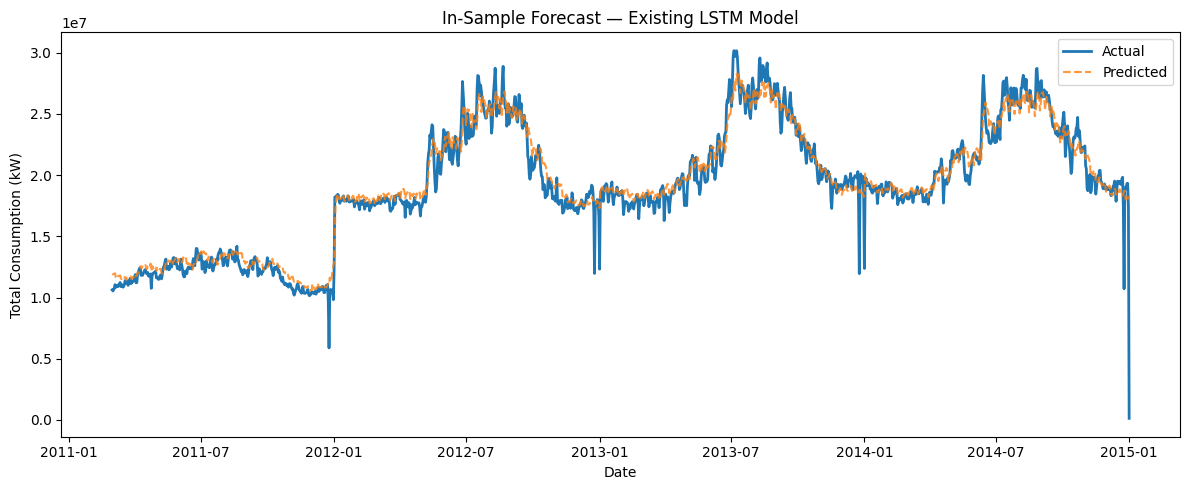

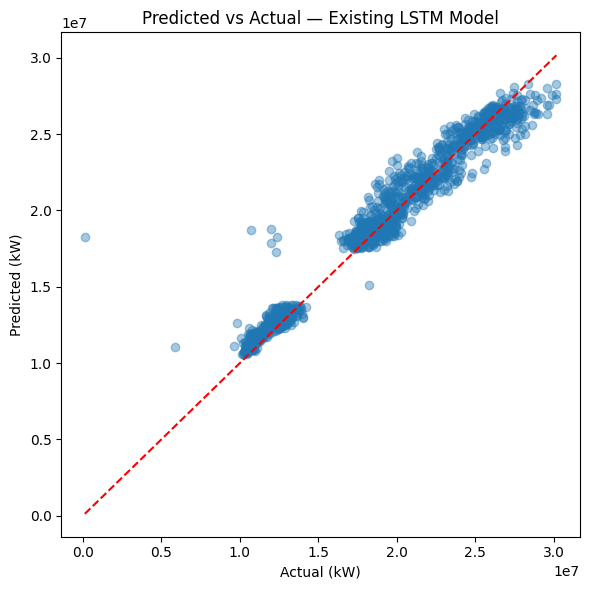

In [ ]:
# Run inference on every input window (tX) with the existing `model`
model.eval()
with torch.no_grad():
    preds_scaled = model(tX.to(device)).cpu().numpy().flatten()

# Invert target scaling back to kW
y_pred = scaler_y.inverse_transform(preds_scaled.reshape(-1,1)).flatten()

y_true = daily['total_kW'].iloc[SEQ_LEN:].values
dates  = daily.index[SEQ_LEN:]

# Time‐series plot: Actual vs Predicted
plt.figure(figsize=(12,5))
plt.plot(dates, y_true, label='Actual',  linewidth=2)
plt.plot(dates, y_pred,  label='Predicted', linestyle='--', alpha=0.8)
plt.title('In‐Sample Forecast — Existing LSTM Model')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# Scatter plot: Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.4)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.title('Predicted vs Actual — Existing LSTM Model')
plt.xlabel('Actual (kW)')
plt.ylabel('Predicted (kW)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, : -self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size-1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size,
                               padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.drop1,
            self.conv2, self.chomp2, self.relu2, self.drop2
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.final_relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.final_relu(out + res)

class TCNForecast(nn.Module):
    def __init__(self, in_feats, channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(channels)
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = in_feats if i == 0 else channels[i-1]
            out_ch = channels[i]
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], 1)

    def forward(self, x):
        # x: (batch, seq_len, in_feats)
        x = x.transpose(1, 2)           # (batch, in_feats, seq_len)
        y = self.network(x)             # (batch, out_ch, seq_len)
        y_last = y[:, :, -1]            # (batch, out_ch)
        return self.fc(y_last)          # (batch, 1)

# --- 2) Cross-Validation Training ---
channels = [64, 64, 128]  # three TCN layers
tscv = TimeSeriesSplit(n_splits=3)
mae_scores = []

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(tX), start=1):
    X_tr, y_tr = tX[tr_idx], ty[tr_idx]
    X_vl, y_vl = tX[vl_idx], ty[vl_idx]

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=False)
    val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32, shuffle=False)

    model_tcn = TCNForecast(in_feats=X_seq.shape[2], channels=channels).to(device)
    optimizer = optim.Adam(model_tcn.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    epochs = 100
    for epoch in range(1, epochs+1):
        # Train
        model_tcn.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model_tcn(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            tr_loss += loss.item()*xb.size(0)
        tr_loss /= len(train_loader.dataset)
        train_losses.append(tr_loss)

        # Validate
        model_tcn.eval()
        vl_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model_tcn(xb)
                loss = criterion(out, yb)
                vl_loss += loss.item()*xb.size(0)
        vl_loss /= len(val_loader.dataset)
        val_losses.append(vl_loss)

        if epoch == 1 or epoch % 50 == 0:
            print(f"TCN Fold {fold} | Epoch {epoch:03d} | Train MSE: {tr_loss:.4f} | Val MSE: {vl_loss:.4f}")

    # Final fold MAE
    model_tcn.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            out = model_tcn(xb.to(device)).cpu().numpy()
            preds_s.append(out); acts_s.append(yb.numpy())
    y_pred_s = np.vstack(preds_s).flatten()
    y_val_s  = np.vstack(acts_s).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).flatten()
    y_val  = scaler_y.inverse_transform(y_val_s.reshape(-1,1)).flatten()
    mae = mean_absolute_error(y_val, y_pred)
    mae_scores.append(mae)
    print(f"Fold {fold} MAE (kW): {mae:.1f}\n")

print(f"▶︎ Average TCN MAE: {np.mean(mae_scores):.1f} kW")

# Save the last trained model for inference
tcn_model = model_tcn


TCN Fold 1 | Epoch 001 | Train MSE: 0.0295 | Val MSE: 0.1032
TCN Fold 1 | Epoch 050 | Train MSE: 0.0008 | Val MSE: 0.0025
TCN Fold 1 | Epoch 100 | Train MSE: 0.0004 | Val MSE: 0.0018
Fold 1 MAE (kW): 932408.1

TCN Fold 2 | Epoch 001 | Train MSE: 0.0259 | Val MSE: 0.0150
TCN Fold 2 | Epoch 050 | Train MSE: 0.0014 | Val MSE: 0.0019
TCN Fold 2 | Epoch 100 | Train MSE: 0.0019 | Val MSE: 0.0028
Fold 2 MAE (kW): 1304614.0

TCN Fold 3 | Epoch 001 | Train MSE: 0.0254 | Val MSE: 0.0825
TCN Fold 3 | Epoch 050 | Train MSE: 0.0010 | Val MSE: 0.0025
TCN Fold 3 | Epoch 100 | Train MSE: 0.0010 | Val MSE: 0.0027
Fold 3 MAE (kW): 973502.9

▶︎ Average TCN MAE: 1070175.0 kW


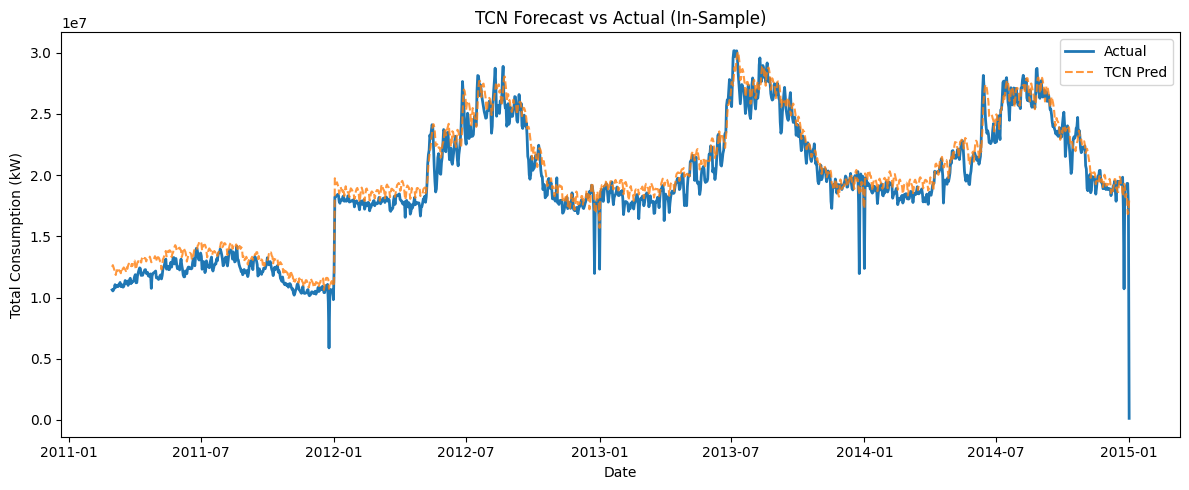

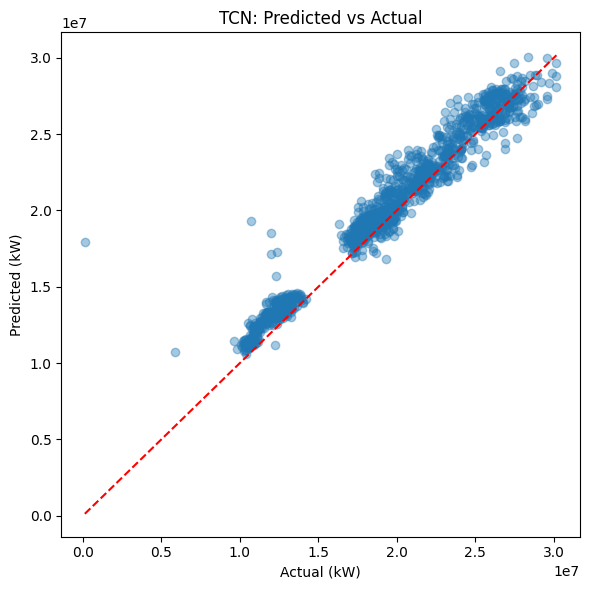

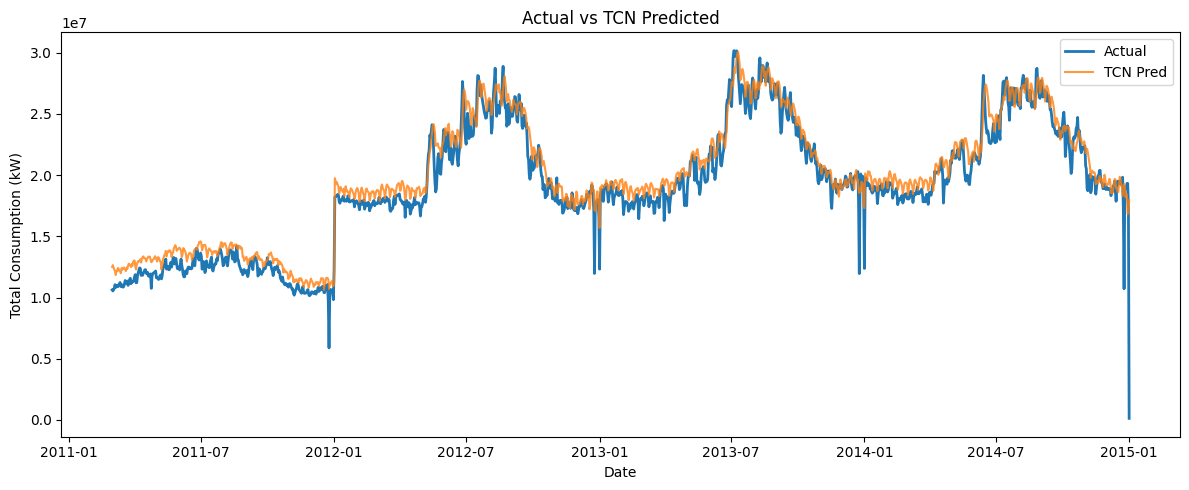

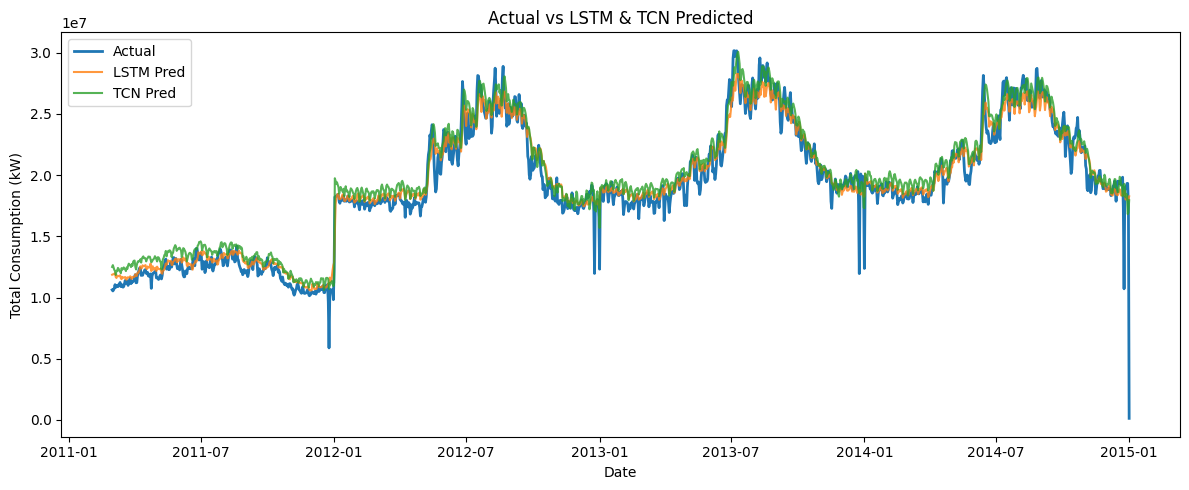

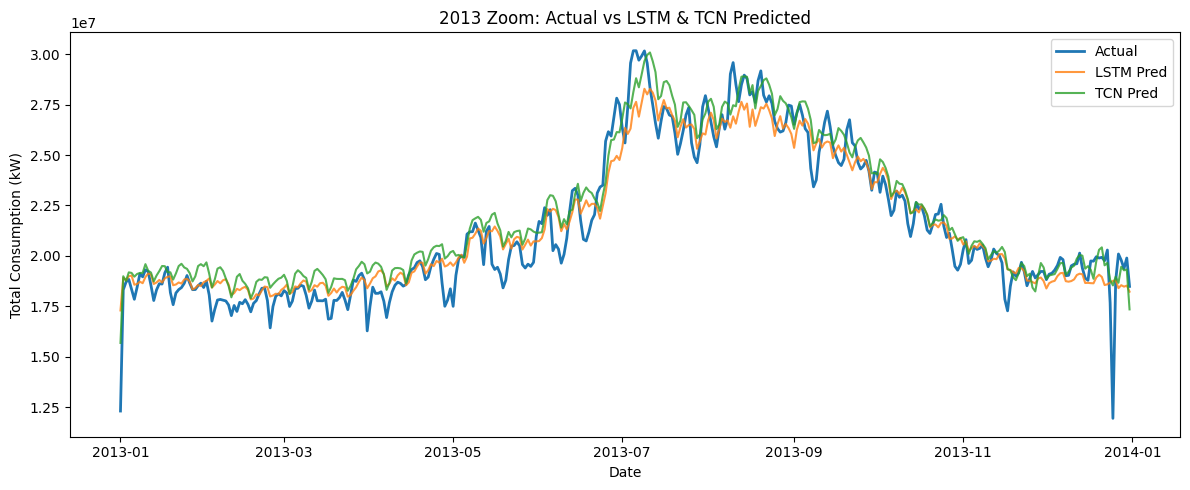

In [ ]:
# 1) Run inference on all in-sample windows
model_tcn = tcn_model
model_tcn.eval()
with torch.no_grad():
    preds_scaled = model_tcn(tX.to(device)).cpu().numpy().flatten()

# 2) Invert scaling
y_pred_tcn = scaler_y.inverse_transform(preds_scaled.reshape(-1,1)).flatten()

y_true = daily['total_kW'].iloc[SEQ_LEN:].values

dates = daily.index[SEQ_LEN:]

# 3) Time-series plot
plt.figure(figsize=(12,5))
plt.plot(dates, y_true,   label='Actual', linewidth=2)
plt.plot(dates, y_pred_tcn, label='TCN Pred', linestyle='--', alpha=0.8)
plt.title('TCN Forecast vs Actual (In-Sample)')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# 4) Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_tcn, alpha=0.4)
lims = [min(y_true.min(), y_pred_tcn.min()), max(y_true.max(), y_pred_tcn.max())]
plt.plot(lims, lims, 'r--')
plt.title('TCN: Predicted vs Actual')
plt.xlabel('Actual (kW)')
plt.ylabel('Predicted (kW)')
plt.tight_layout()
plt.show()

# 1) Inference for LSTM
model.eval()
with torch.no_grad():
    lstm_s = model(tX.to(device)).cpu().numpy().flatten()
y_pred_lstm = scaler_y.inverse_transform(lstm_s.reshape(-1,1)).flatten()

# 2) Inference for TCN
model_tcn.eval()
with torch.no_grad():
    tcn_s = model_tcn(tX.to(device)).cpu().numpy().flatten()
y_pred_tcn = scaler_y.inverse_transform(tcn_s.reshape(-1,1)).flatten()

# 3) Actual and dates

y_true = daily['total_kW'].iloc[SEQ_LEN:].values

dates = daily.index[SEQ_LEN:]

# 4) Plot Actual vs TCN only
plt.figure(figsize=(12,5))
plt.plot(dates, y_true,      label='Actual', linewidth=2)
plt.plot(dates, y_pred_tcn,  label='TCN Pred', alpha=0.8)
plt.title('Actual vs TCN Predicted')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# 5) Plot Actual vs LSTM vs TCN
plt.figure(figsize=(12,5))
plt.plot(dates, y_true,      label='Actual', linewidth=2)
plt.plot(dates, y_pred_lstm, label='LSTM Pred', alpha=0.8)
plt.plot(dates, y_pred_tcn,  label='TCN Pred', alpha=0.8)
plt.title('Actual vs LSTM & TCN Predicted')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.show()

# Zoom in on a year 2013 and compare
mask = (dates >= '2013-01-01') & (dates <= '2013-12-31')
plt.figure(figsize=(12,5))
plt.plot(dates[mask], y_true[mask],      label='Actual', linewidth=2)
plt.plot(dates[mask], y_pred_lstm[mask], label='LSTM Pred', alpha=0.8)
plt.plot(dates[mask], y_pred_tcn[mask],  label='TCN Pred', alpha=0.8)
plt.title('2013 Zoom: Actual vs LSTM & TCN Predicted')
plt.xlabel('Date')
plt.ylabel('Total Consumption (kW)')
plt.legend()
plt.tight_layout()
plt.show()

AE Epoch 00 | Loss: 0.084630
AE Epoch 10 | Loss: 0.004162
AE Epoch 20 | Loss: 0.003484


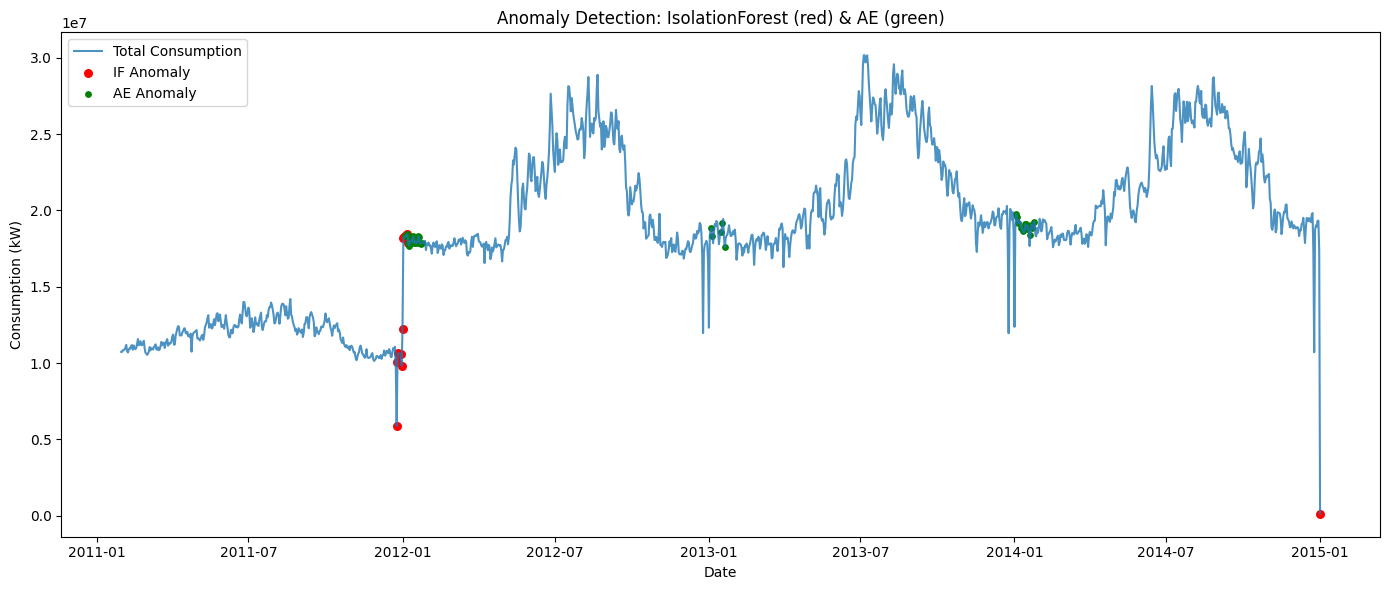

KeyError: 'true_label'

In [ ]:
from sklearn.ensemble import IsolationForest

# Isolation Forest on daily features ---
feature_cols = daily.columns.difference(['total_kW'])
X_feat = daily[feature_cols].values
scaler_if = MinMaxScaler()
X_feat_scaled = scaler_if.fit_transform(X_feat)

iso = IsolationForest(contamination=0.01, random_state=42)
daily['anomaly_if'] = iso.fit_predict(X_feat_scaled)  # +1 normal, -1 anomaly

# MLP Autoencoder on 30-day windows ---
# Prepare flattened sequences
dates = daily.index[SEQ_LEN:]
X_windows = X_seq  # from previous cells: shape (n_samples, SEQ_LEN, n_feats)
n_samples, slen, n_feats = X_windows.shape
X_flat = X_windows.reshape(n_samples, slen * n_feats)

ae_dataset = TensorDataset(torch.from_numpy(X_flat).float())
ae_loader  = DataLoader(ae_dataset, batch_size=32, shuffle=True)

class AE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

input_dim = slen * n_feats
model_ae = AE(input_dim, hidden_dim=256).to(device)
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

model_ae.train()
for epoch in range(30):
    epoch_loss = 0.0
    for (xb,) in ae_loader:
        xb = xb.to(device)
        out = model_ae(xb)
        loss = criterion(out, xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= n_samples
    if epoch % 10 == 0 or epoch == 0:
        print(f"AE Epoch {epoch:02d} | Loss: {epoch_loss:.6f}")

model_ae.eval()
with torch.no_grad():
    X_tensor = torch.from_numpy(X_flat).float().to(device)
    recon = model_ae(X_tensor).cpu().numpy()
mse = ((recon - X_flat) ** 2).mean(axis=1)
thresh = mse.mean() + 3 * mse.std()

daily['ae_error'] = np.nan
daily.loc[dates, 'ae_error'] = mse
daily['anomaly_ae'] = 0
daily.loc[dates[mse > thresh], 'anomaly_ae'] = 1

plt.figure(figsize=(14,6))
plt.plot(daily.index, daily['total_kW'], label='Total Consumption', alpha=0.8)
# Isolation Forest anomalies
if_anoms = daily[daily['anomaly_if'] == -1]
plt.scatter(if_anoms.index, if_anoms['total_kW'], color='r', label='IF Anomaly', s=30)
# Autoencoder anomalies
ae_anoms = daily[daily['anomaly_ae'] == 1]
plt.scatter(ae_anoms.index, ae_anoms['total_kW'], color='g', label='AE Anomaly', s=15)
plt.title('Anomaly Detection: IsolationForest (red) & AE (green)')
plt.xlabel('Date'); plt.ylabel('Consumption (kW)')
plt.legend(); plt.tight_layout(); plt.show()
